In [20]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

# Import model selection and evaluation utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

# Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [21]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [22]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [23]:
# Check for missing values in each column
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [24]:
# Handle missing values by replacing them with the mean of each column
# This is a simple imputation strategy
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())

In [25]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [26]:
# Separate features (X) and target (y)
# X contains Age and Fare columns (columns 1 and 2)
# y contains the Survived column (column 0)
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [27]:
# Split data into training (80%) and testing (20%) sets
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

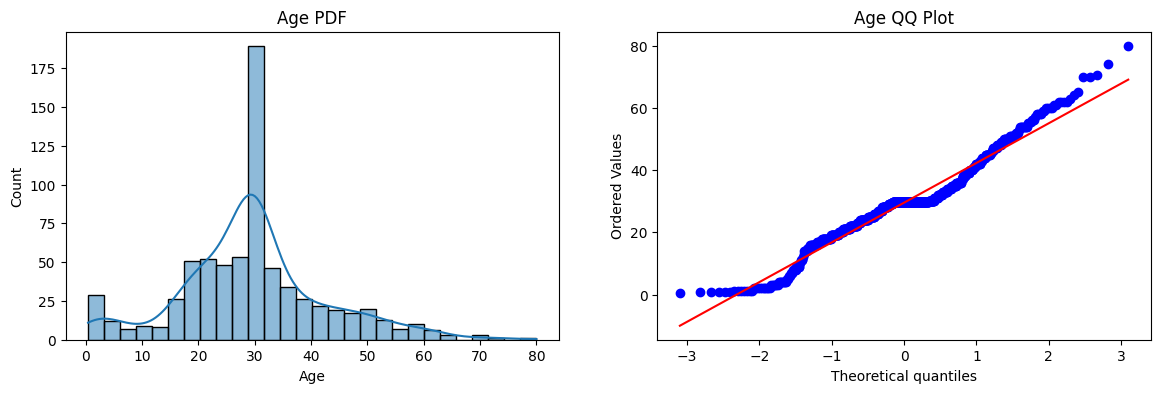

In [28]:
# Visualize Age distribution before transformation
# PDF (Probability Density Function) - Histogram with KDE:
#   - Shows the shape of the distribution (symmetric, skewed, etc.)
#   - If bell-shaped, data is normally distributed (good for linear models)
#   - If skewed, data is not normal (may need transformation for better model performance)
# Q-Q Plot (Quantile-Quantile Plot):
#   - Compares data quantiles against theoretical normal distribution quantiles
#   - If points lie on the red diagonal line, data is normally distributed
#   - If points deviate from the line, it indicates non-normality (heavy tails, skewness)
#   - Points above/below the line at the ends indicate positive/negative skew
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

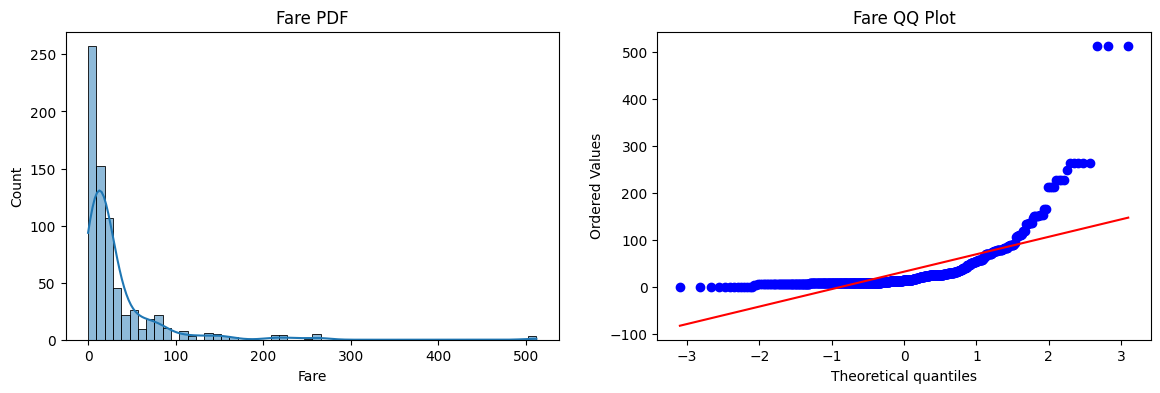

In [29]:
# Visualize Fare distribution before transformation
# PDF (Probability Density Function) - Histogram with KDE:
#   - Reveals the shape and spread of the Fare distribution
#   - A highly right-skewed distribution (tail on right side) suggests most passengers paid lower fares
#   - Skewed data can hurt linear model performance as they assume normality
# Q-Q Plot (Quantile-Quantile Plot):
#   - Shows how far Fare is from a normal distribution
#   - Curves away from the diagonal line indicate departure from normality
#   - Heavy deviation especially at tail ends shows strong skewness
#   - This is a candidate for transformation (log, sqrt, etc.)
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [30]:
# Initialize two classification models to compare performance
# LogisticRegression (LR) is a linear model
# DecisionTreeClassifier (DT) is a tree-based nonlinear model
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [31]:
# Train both models on the original (untransformed) data
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

# Evaluate model performance using accuracy
# This is the baseline accuracy without any feature transformation
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.664804469273743


In [32]:
# Create a FunctionTransformer that applies the log1p function
# log1p computes log(1 + x) which handles zero and negative values
# This transformation can help normalize skewed distributions
trf = FunctionTransformer(func=np.log1p) # log1p is used to handle zero values in Fare

In [33]:
# Apply the log transformation to both training and test data
# fit_transform: learn the transformation parameters from X_train and apply it
# transform: apply the learned transformation to X_test
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [34]:
# Train models on transformed data (applying log transformation to all features)
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

# Make predictions on transformed test data
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

# Compare accuracy with transformed features vs. baseline
# We should see if transformation improves model performance
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6871508379888268


In [35]:
# Apply transformation to the entire dataset for cross-validation
# This ensures all data uses the same transformation parameters
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

# Use 10-fold cross-validation to get more robust accuracy estimates
# cross_val_score provides multiple accuracy values (one per fold) think it like we are doing it 10 times and comparing all 10 results mean values
# We take the mean to get the average cross-validation accuracy
print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6577403245942571


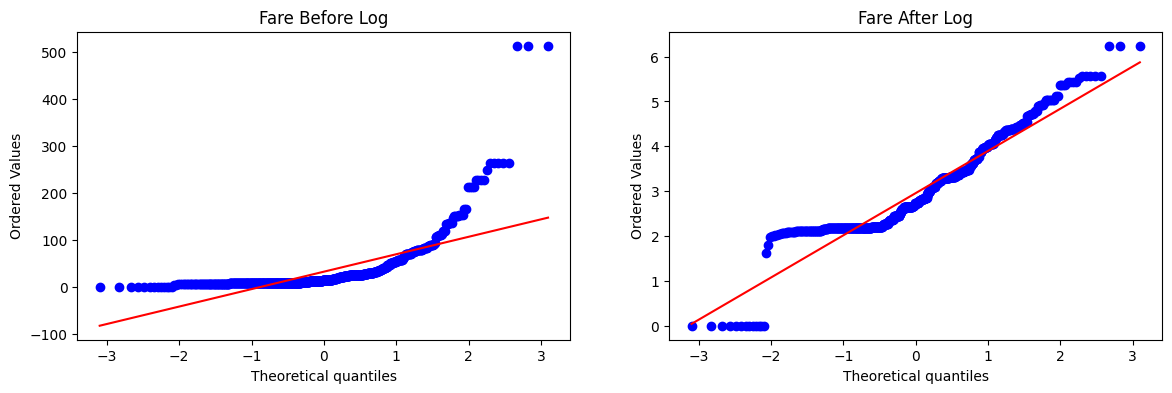

In [36]:
# Compare Fare distribution before and after log transformation
# Left Q-Q Plot (Before Log): 
#   - Shows original Fare has significant skewness (points deviate from diagonal)
#   - Indicates the need for transformation to normalize the distribution
# Right Q-Q Plot (After Log):
#   - Points should align closer to the diagonal line after log transformation
#   - Better alignment means data is now closer to normal distribution
#   - More normal distribution helps linear models like Logistic Regression perform better
# Insight: If points move closer to the diagonal after transformation, the transformation is working!
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

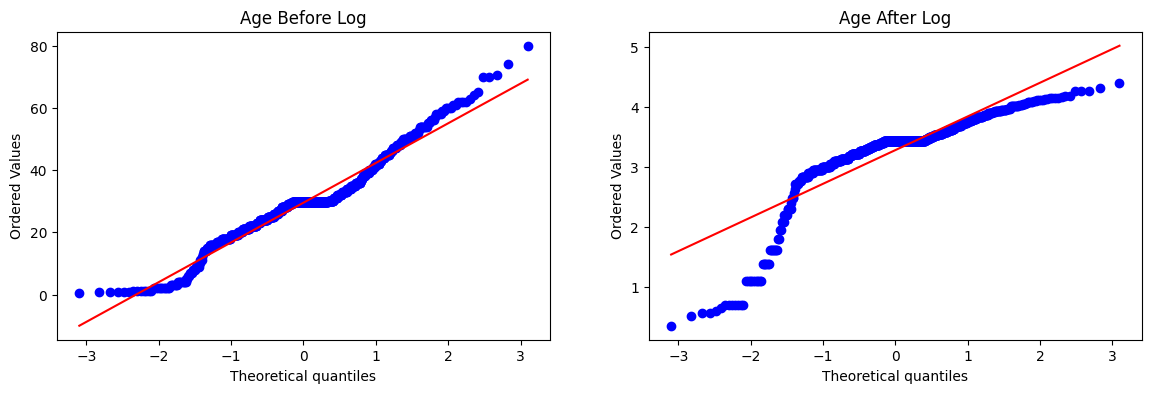

In [37]:
# Compare Age distribution before and after log transformation
# Left Q-Q Plot (Before Log):
#   - Shows how Age deviates from normal distribution (if at all)
#   - Age typically has less skewness than Fare in this dataset
# Right Q-Q Plot (After Log):
#   - Shows the effect of log transformation on Age distribution
#   - Compare the alignment: does it improve or stay similar?
#   - If Age was already close to normal, transformation might have minimal effect (in this case it got worse then earlier because it was not right skewed data)
# Insight: Comparing before/after helps determine if transformation is beneficial for each feature
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [38]:
# Train models on selectively transformed data (only Fare is transformed)
# This allows comparison: transforming only one feature vs. all features
# Define a ColumnTransformer that applies log1p only to Fare (trf2)
trf2 = ColumnTransformer([('fare_log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')
# Fit on X_train and transform both train and test
X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

# Make predictions and evaluate
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

# Compare accuracy when only Fare is transformed
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6815642458100558


In [39]:
# Apply selective transformation (Fare only) to entire dataset for cross-validation
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

# Evaluate using 10-fold cross-validation to get robust accuracy estimates
# This compares the performance when only Fare is transformed
print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6599625468164794


In [40]:
# Define a reusable function to test any transformation function
def apply_transform(transform):
    # Extract features and target
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    # Create a ColumnTransformer with the provided transformation function
    # Applied only to the 'Fare' column while keeping other columns unchanged
    trf = ColumnTransformer([('transform',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    # Apply the transformation
    X_trans = trf.fit_transform(X)
    
    # Initialize a logistic regression classifier
    clf = LogisticRegression()
    
    # Evaluate the model using 10-fold cross-validation
    # This shows how the specific transformation affects model performance
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    # Visualize the effect of transformation on the Fare distribution
    # This helps us understand if the transformation successfully normalizes the data
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    # Q-Q plot of original Fare
    # Shows points deviating from diagonal = skewed/non-normal distribution
    # Heavy right tail indicates right-skewed data
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    # Q-Q plot of transformed Fare (first column of X_trans)
    # If points align closer to diagonal, transformation successfully normalized data
    # Better normalization typically leads to improved linear model performance
    # The degree of improvement tells us if this transformation is effective
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6712609238451936


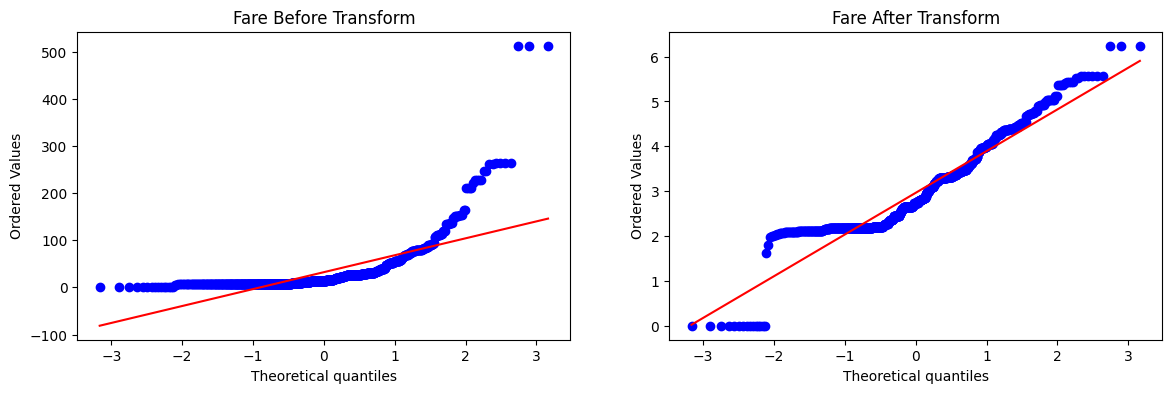

In [41]:
# Test the apply_transform function with np.log1p as the transformation function
# log1p is a robust transformation that handles zero and small values gracefully
# log1p computes log(1 + x), which is excellent for normalizing right-skewed distributions
# This demonstrates how different transformations affect the Fare distribution
# and the resulting model accuracy
apply_transform(np.log1p)

Accuracy 0.616167290886392


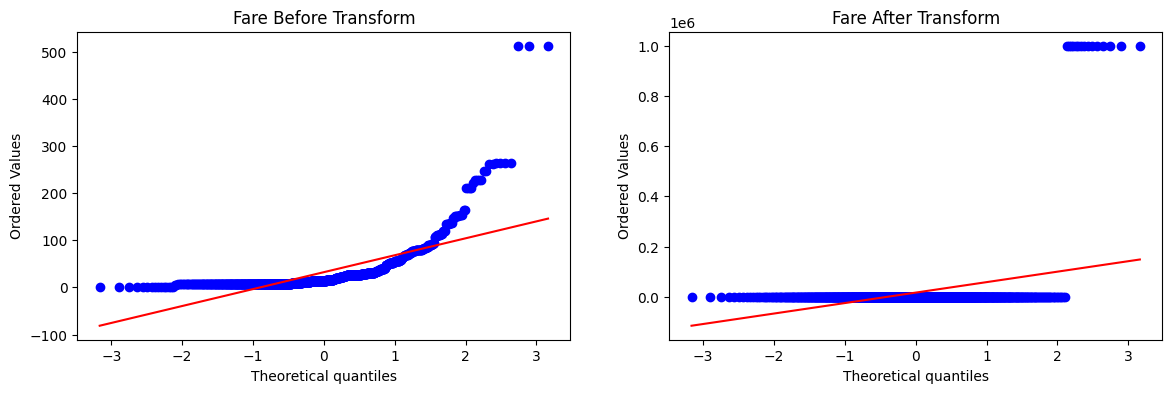

In [42]:
# Test with reciprocal-square transformation (1 / (Fare^2 + eps))
# Add a tiny epsilon to avoid division-by-zero issues on zero fares
apply_transform(lambda x: 1 / (np.square(x) + 1e-6))

Accuracy 0.6611485642946316


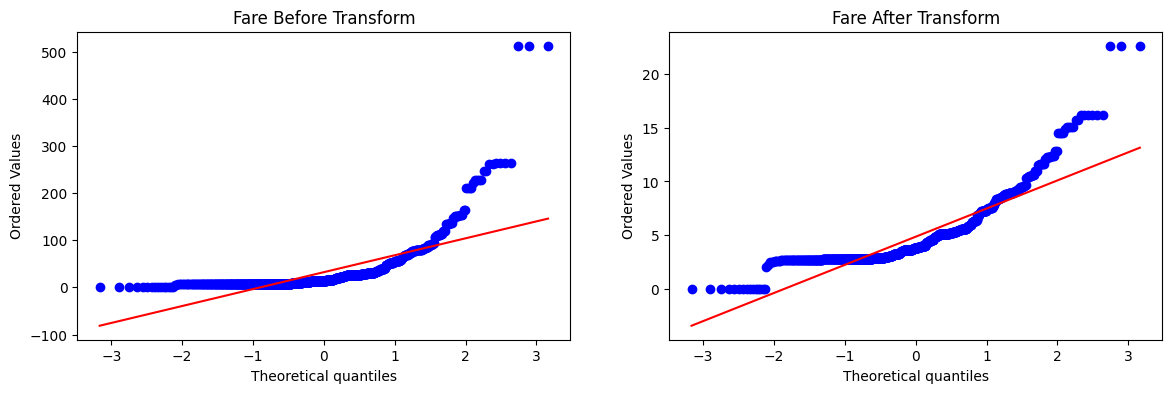

In [43]:
# Test with square-root transformation
apply_transform(np.sqrt)

Accuracy 0.61729088639201


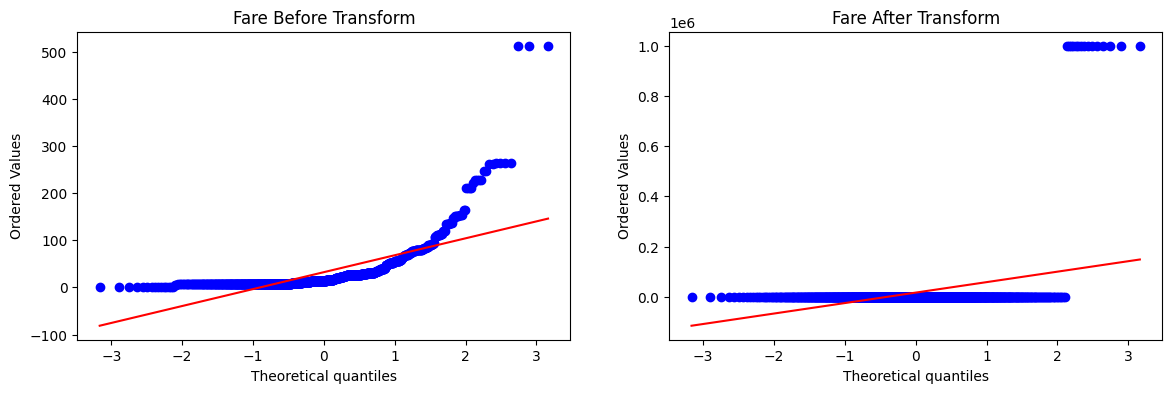

In [44]:
# Test with plain reciprocal transformation (1 / (Fare + eps))
# Use a small epsilon to avoid division by zero
apply_transform(lambda x: 1 / (x + 1e-6))

Accuracy 0.6431335830212235


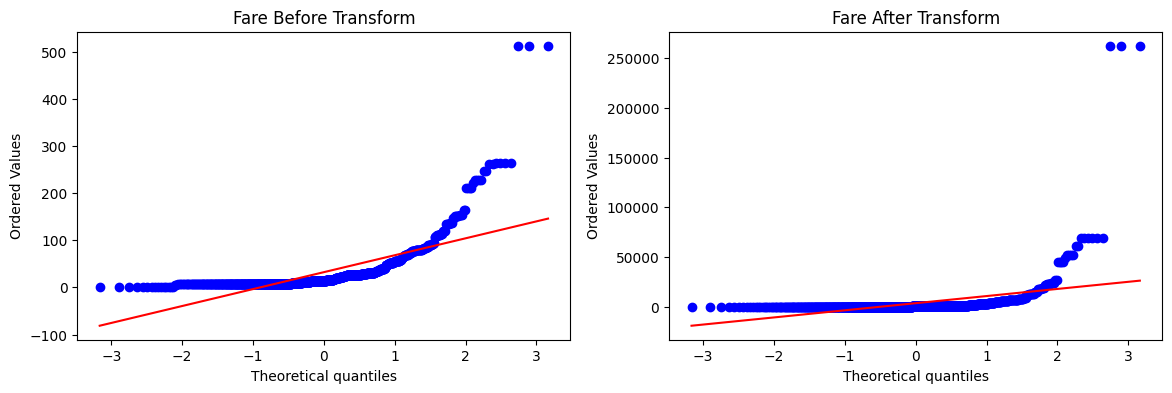

In [45]:
# Test with plain square transformation
apply_transform(np.square)